In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Tenant_churn_prediction.csv')
df

,Tenant_id,signup_date,Years_in_property,Tenant_age,Tenant_gender,region,income_level,subscription_type,Rent_amount,Total_rent_paid,...,avg_session_duration_minutes,number_of_logins_per_month,number_of_support_tickets,satisfaction_score,Rent_payment_method,Lease_type,last_login_days_ago,promotional_response,discount_used,Tenant_churn
0,CUST_000001,17-08-2022,28,47,Male,North America,low,basic,35.22,1034.06,...,55.3,12,1,5,Credit Card,monthly,4,no,yes,0
1,CUST_000002,21-02-2022,34,40,Male,Europe,low,standard,63.56,2065.11,...,25.7,18,1,3,Bank Transfer,yearly,13,no,yes,0
2,CUST_000003,18-07-2023,17,49,Female,Asia Pacific,low,standard,74.37,1248.11,...,9.0,8,6,5,Digital Wallet,monthly,54,no,yes,1
3,CUST_000004,17-05-2023,19,60,Female,Latin America,medium,premium,98.28,1540.50,...,99.4,30,1,3,Credit Card,monthly,6,no,no,0
4,CUST_000005,03-04-2023,20,39,Female,Asia Pacific,medium,standard,61.47,1166.17,...,8.4,8,3,5,Digital Wallet,yearly,59,no,yes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,CUST_014996,16-11-2024,1,31,Female,Latin America,low,standard,60.82,53.29,...,38.7,13,2,3,Credit Card,monthly,67,no,no,1
14996,CUST_014997,11-10-2024,2,56,Female,Latin America,low,basic,34.68,75.17,...,69.1,23,3,2,PayPal,yearly,83,yes,no,1
14997,CUST_014998,24-07-2023,17,57,Female,North America,low,basic,23.80,350.56,...,31.1,13,2,3,Credit Card,yearly,17,no,no,0
14998,CUST_014999,19-02-2023,22,31,Male,Latin America,medium,standard,67.70,1337.17,...,38.0,16,1,5,Credit Card,yearly,4,yes,no,0


In [3]:
df.Rent_payment_method.value_counts()

Rent_payment_method
Credit Card       7417
PayPal            3888
Bank Transfer     2227
Digital Wallet    1468
Name: count, dtype: int64

In [4]:
df.region.value_counts()

region
North America    5377
Europe           4414
Asia Pacific     2938
Latin America    1537
Middle East       734
Name: count, dtype: int64

In [5]:
df.subscription_type.value_counts()

subscription_type
basic       6428
standard    6107
premium     2465
Name: count, dtype: int64

In [6]:
df.Lease_type.value_counts()

Lease_type
yearly     8460
monthly    6540
Name: count, dtype: int64

In [7]:
df.head()

,Tenant_id,signup_date,Years_in_property,Tenant_age,Tenant_gender,region,income_level,subscription_type,Rent_amount,Total_rent_paid,...,avg_session_duration_minutes,number_of_logins_per_month,number_of_support_tickets,satisfaction_score,Rent_payment_method,Lease_type,last_login_days_ago,promotional_response,discount_used,Tenant_churn
0,CUST_000001,17-08-2022,28,47,Male,North America,low,basic,35.22,1034.06,...,55.3,12,1,5,Credit Card,monthly,4,no,yes,0
1,CUST_000002,21-02-2022,34,40,Male,Europe,low,standard,63.56,2065.11,...,25.7,18,1,3,Bank Transfer,yearly,13,no,yes,0
2,CUST_000003,18-07-2023,17,49,Female,Asia Pacific,low,standard,74.37,1248.11,...,9.0,8,6,5,Digital Wallet,monthly,54,no,yes,1
3,CUST_000004,17-05-2023,19,60,Female,Latin America,medium,premium,98.28,1540.50,...,99.4,30,1,3,Credit Card,monthly,6,no,no,0
4,CUST_000005,03-04-2023,20,39,Female,Asia Pacific,medium,standard,61.47,1166.17,...,8.4,8,3,5,Digital Wallet,yearly,59,no,yes,0


In [8]:
df.columns

Index(['Tenant_id', 'signup_date', 'Years_in_property', 'Tenant_age',
       'Tenant_gender', 'region', 'income_level', 'subscription_type',
       'Rent_amount', 'Total_rent_paid', 'usage_frequency',
       'avg_session_duration_minutes', 'number_of_logins_per_month',
       'number_of_support_tickets', 'satisfaction_score',
       'Rent_payment_method', 'Lease_type', 'last_login_days_ago',
       'promotional_response', 'discount_used', 'Tenant_churn'],
      dtype='object')

In [9]:
df.columns = df.columns.str.strip() # to remove the extra spaces:

In [10]:
df.columns

Index(['Tenant_id', 'signup_date', 'Years_in_property', 'Tenant_age',
       'Tenant_gender', 'region', 'income_level', 'subscription_type',
       'Rent_amount', 'Total_rent_paid', 'usage_frequency',
       'avg_session_duration_minutes', 'number_of_logins_per_month',
       'number_of_support_tickets', 'satisfaction_score',
       'Rent_payment_method', 'Lease_type', 'last_login_days_ago',
       'promotional_response', 'discount_used', 'Tenant_churn'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Tenant_id                     15000 non-null  object 
 1   signup_date                   15000 non-null  object 
 2   Years_in_property             15000 non-null  int64  
 3   Tenant_age                    15000 non-null  int64  
 4   Tenant_gender                 15000 non-null  object 
 5   region                        15000 non-null  object 
 6   income_level                  15000 non-null  object 
 7   subscription_type             15000 non-null  object 
 8   Rent_amount                   15000 non-null  float64
 9   Total_rent_paid               15000 non-null  float64
 10  usage_frequency               15000 non-null  object 
 11  avg_session_duration_minutes  15000 non-null  float64
 12  number_of_logins_per_month    15000 non-null  int64  
 13  n

In [12]:
df.shape

(15000, 21)

In [13]:
df.isnull().sum()

Tenant_id                       0
signup_date                     0
Years_in_property               0
Tenant_age                      0
Tenant_gender                   0
region                          0
income_level                    0
subscription_type               0
Rent_amount                     0
Total_rent_paid                 0
usage_frequency                 0
avg_session_duration_minutes    0
number_of_logins_per_month      0
number_of_support_tickets       0
satisfaction_score              0
Rent_payment_method             0
Lease_type                      0
last_login_days_ago             0
promotional_response            0
discount_used                   0
Tenant_churn                    0
dtype: int64

In [14]:
# Count how many duplicates exist
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [15]:
# copy the data into new dataframe
df_copy = df.copy()
df_copy.drop(columns=['Tenant_id','signup_date'],axis=1,inplace=True)

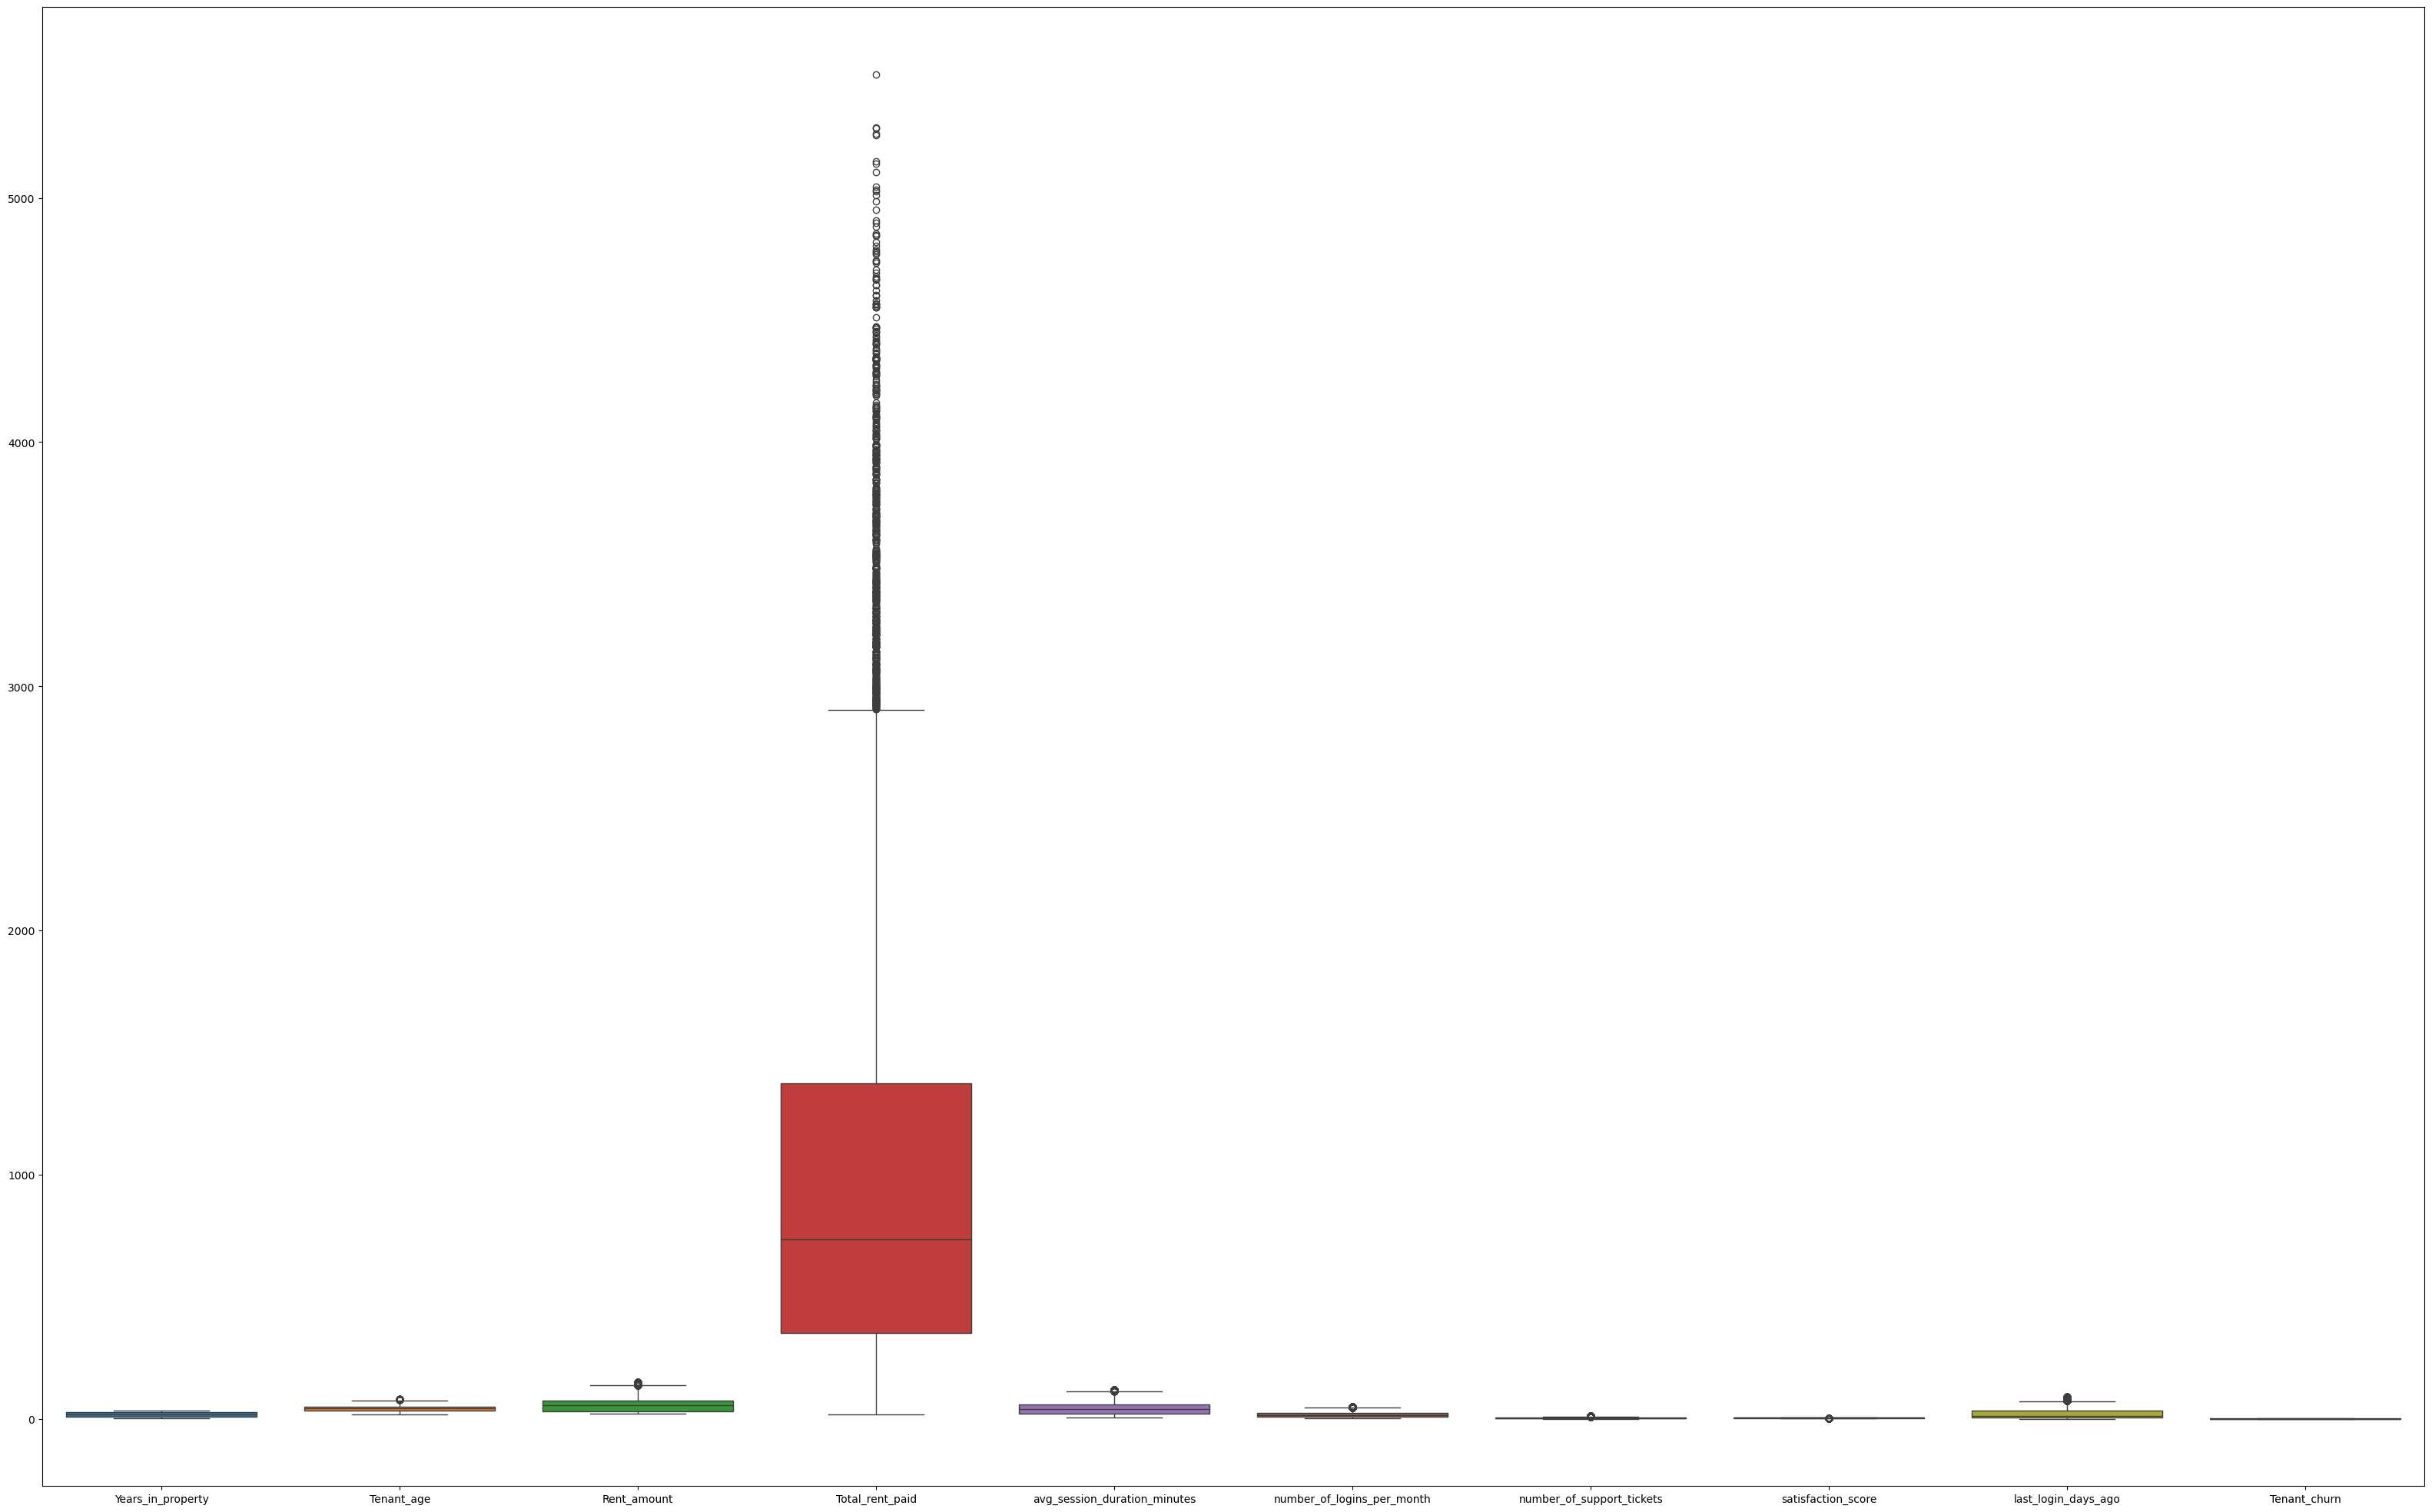

In [16]:
#checking the outliers
plt.figure(figsize=(40,25))
sns.boxplot(df_copy)
plt.show()

In [17]:
# remove the outliers
# calculate the outliers
# Example: remove outliers from column 'age'
Q1 = df['Total_rent_paid'].quantile(0.25)   # 25th percentile
Q3 = df['Total_rent_paid'].quantile(0.75)   # 75th percentile
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_no_outliers = df[(df['Total_rent_paid'] >= lower_bound) & (df['Total_rent_paid'] <= upper_bound)]


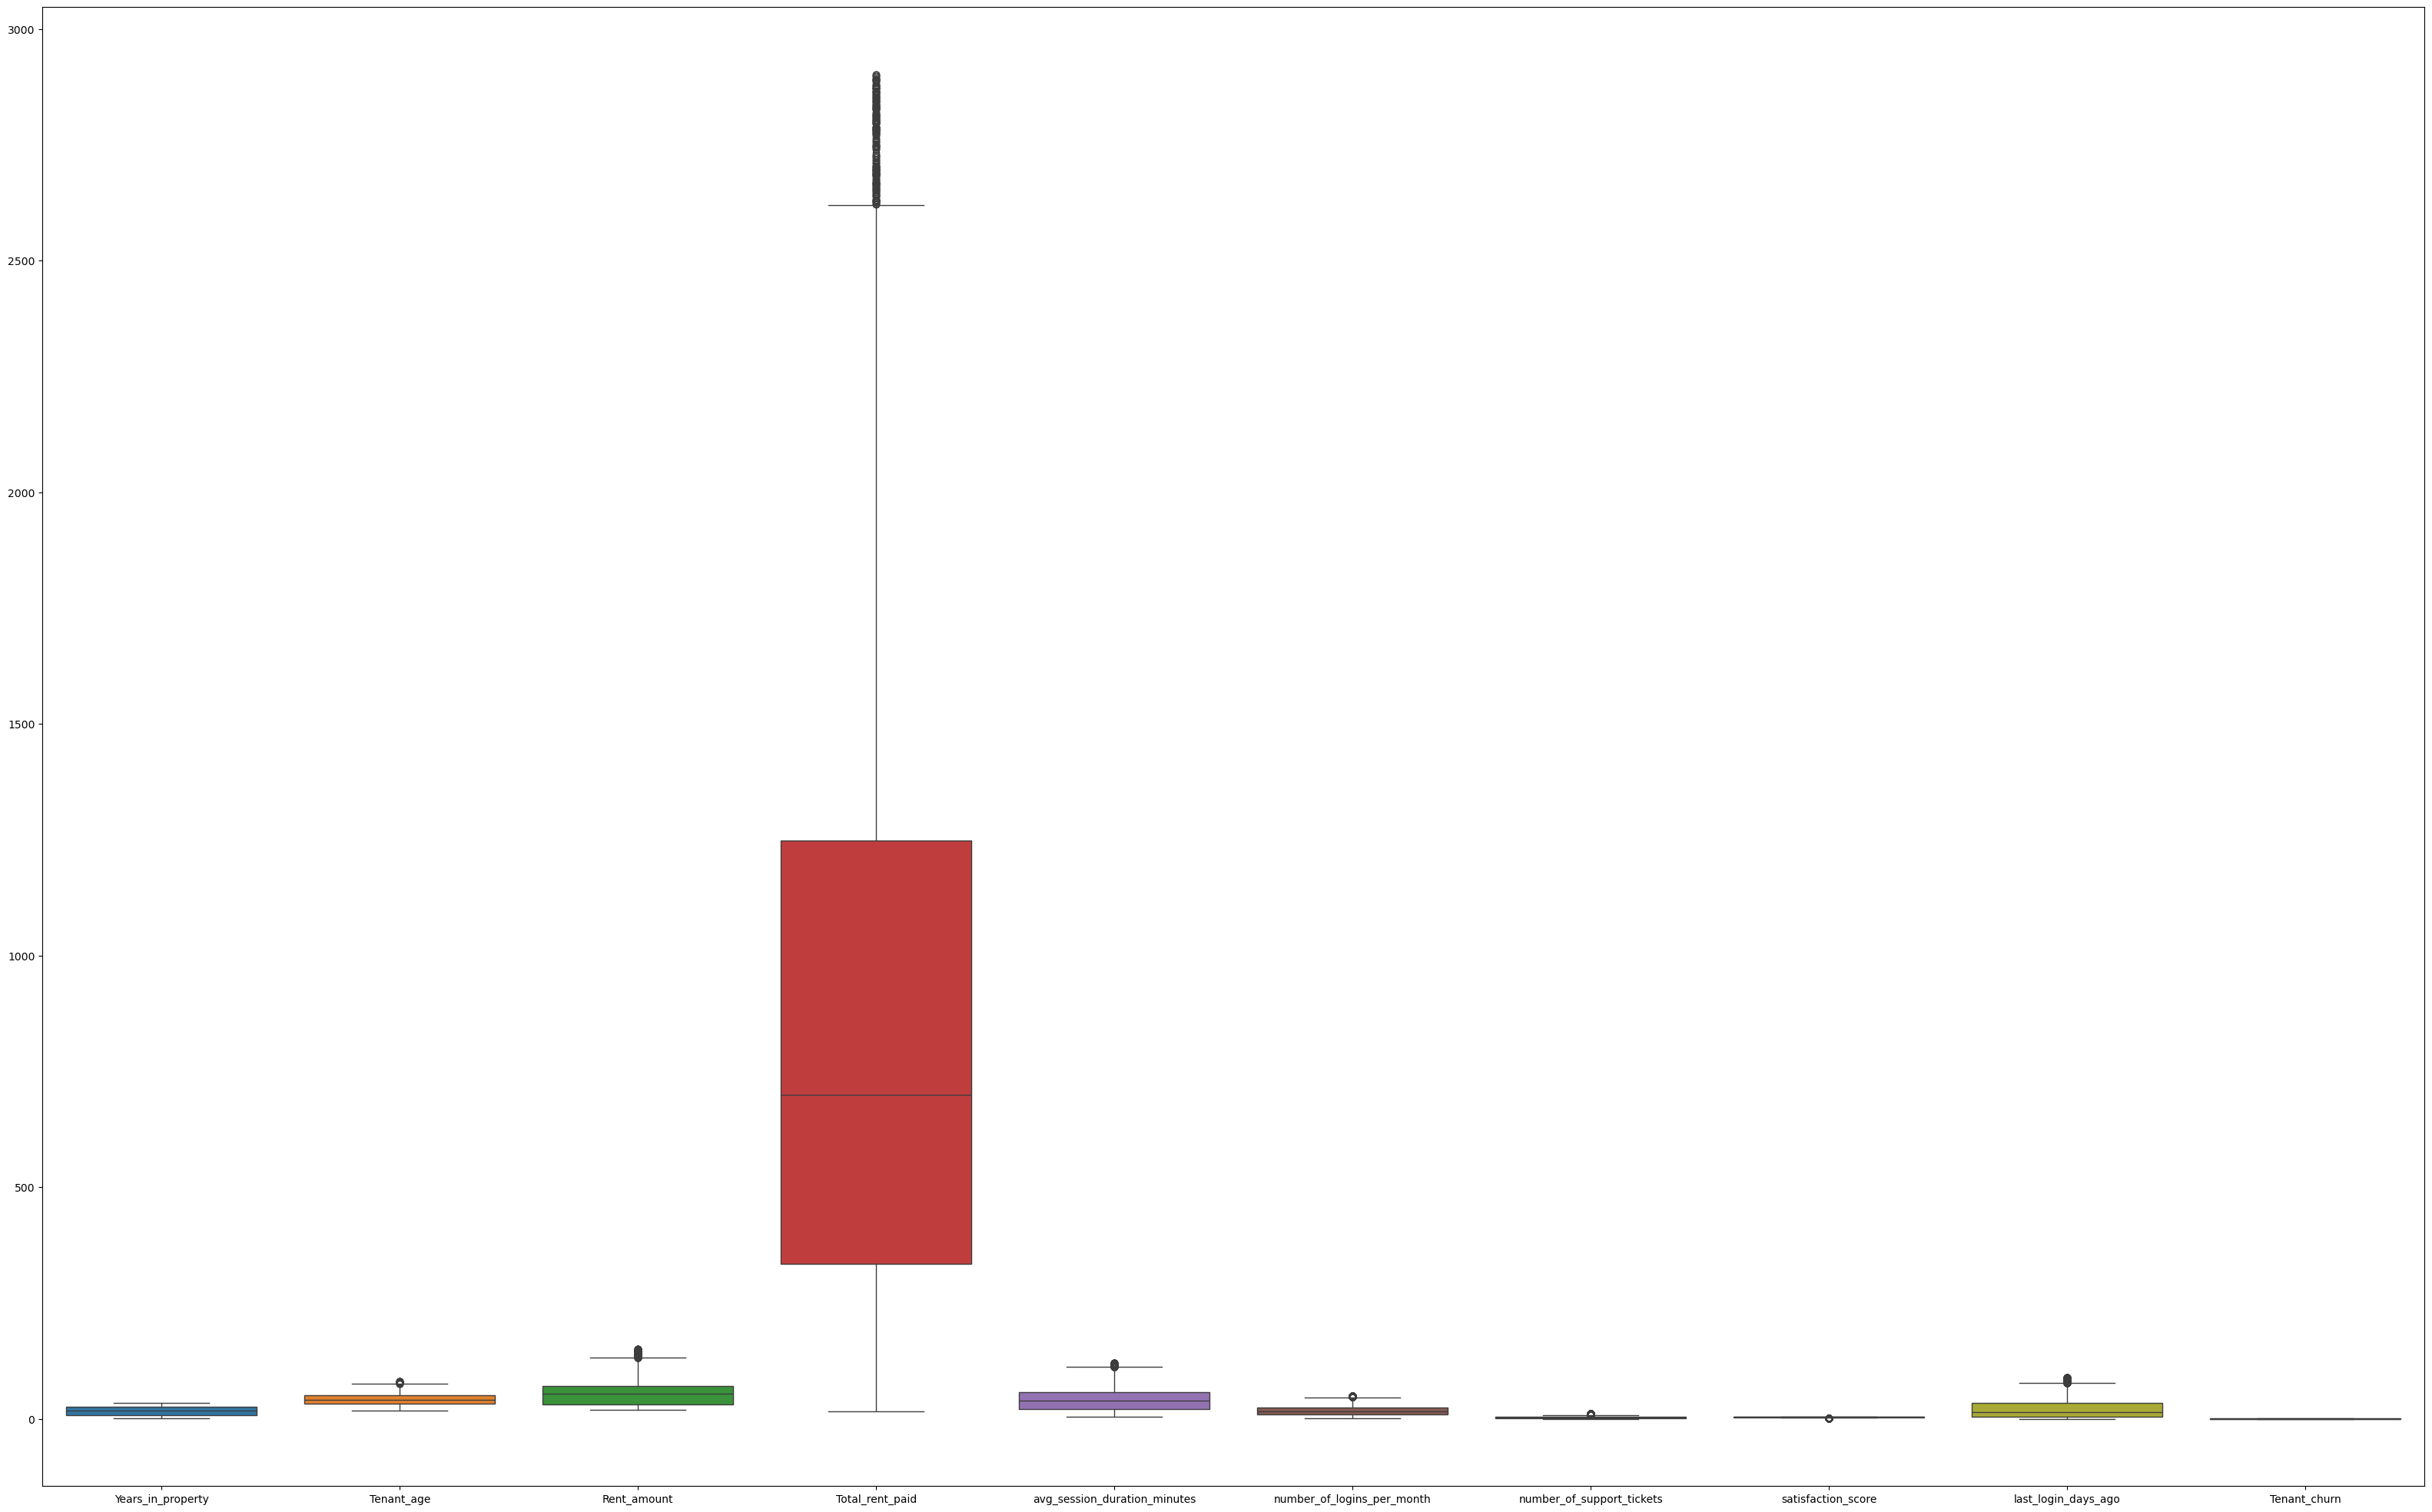

In [18]:
plt.figure(figsize=(40,25))
sns.boxplot(df_no_outliers)
plt.show()

In [19]:
# Function to remove outliers using IQR
def remove_outliers_iqr(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)   # 25th percentile
        Q3 = df[col].quantile(0.75)   # 75th percentile
        IQR = Q3 - Q1                 # Interquartile Range
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Keep only values within bounds
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
        
    # Example usage: remove outliers from selected numeric columns
    df_no_outliers = remove_outliers_iqr(df, ['Tenant_age','Rent_amount','Total_rent_paid'])
    return df_no_outliers
print("Original dataset size:", df.shape)
print("After removing outliers:", df_no_outliers.shape)


Original dataset size: (15000, 21)
After removing outliers: (14358, 21)


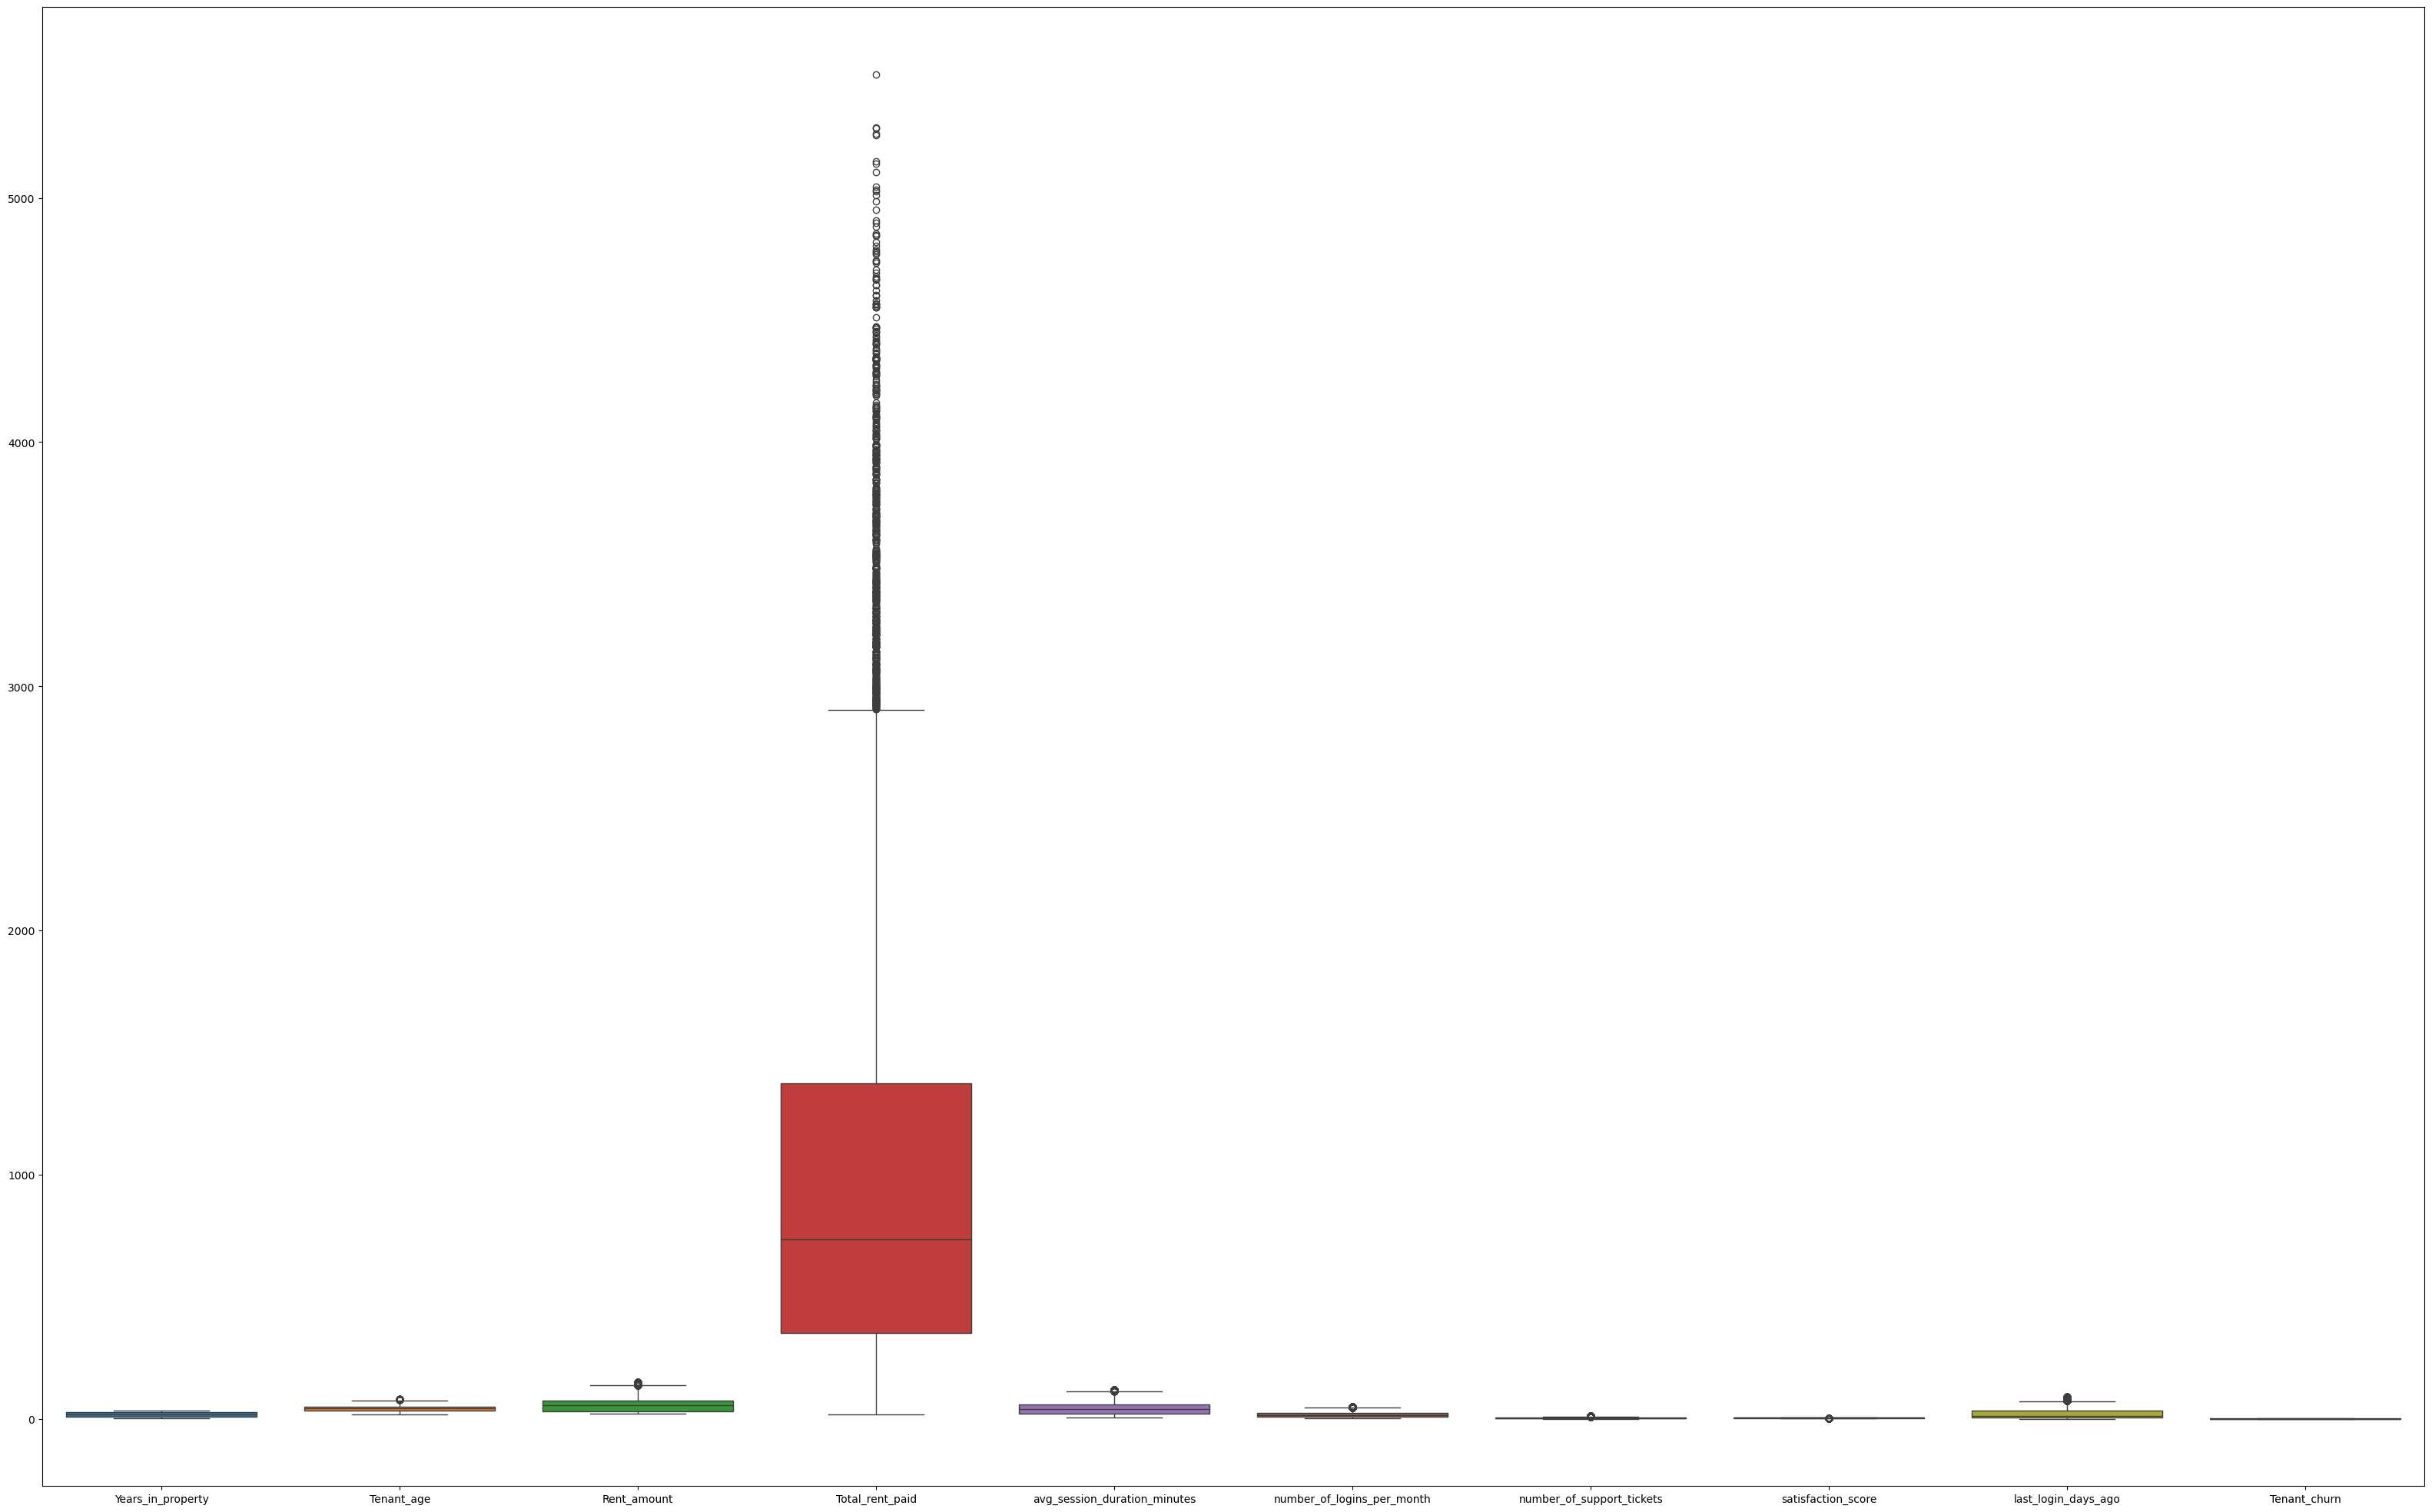

In [20]:
plt.figure(figsize=(40,25))
sns.boxplot(df)
plt.show()

In [21]:
# Features selection in numerical with correlation
num_columns= df_copy.select_dtypes(exclude=object).columns
print("\nNumerical columns:", num_columns.tolist())


Numerical columns: ['Years_in_property', 'Tenant_age', 'Rent_amount', 'Total_rent_paid', 'avg_session_duration_minutes', 'number_of_logins_per_month', 'number_of_support_tickets', 'satisfaction_score', 'last_login_days_ago', 'Tenant_churn']


In [22]:
df_copy[num_columns].corr()

,Years_in_property,Tenant_age,Rent_amount,Total_rent_paid,avg_session_duration_minutes,number_of_logins_per_month,number_of_support_tickets,satisfaction_score,last_login_days_ago,Tenant_churn
Years_in_property,1.000000,-0.009194,-0.000998,0.662814,-0.012988,-0.010783,-0.131862,0.091599,-0.119839,-0.239026
Tenant_age,-0.009194,1.000000,0.028310,0.011781,0.007470,0.008811,-0.002159,-0.005927,0.013446,0.006893
Rent_amount,-0.000998,0.028310,1.000000,0.634164,0.304315,0.308904,-0.058143,0.042608,-0.177398,-0.107328
Total_rent_paid,0.662814,0.011781,0.634164,1.000000,0.188262,0.190737,-0.119793,0.080869,-0.197224,-0.226547
avg_session_duration_minutes,-0.012988,0.007470,0.304315,0.188262,1.000000,0.776635,-0.086456,0.075187,-0.385933,-0.167620
number_of_logins_per_month,-0.010783,0.008811,0.308904,0.190737,0.776635,1.000000,-0.083597,0.069643,-0.372261,-0.160164
number_of_support_tickets,-0.131862,-0.002159,-0.058143,-0.119793,-0.086456,-0.083597,1.000000,-0.313925,0.337940,0.564679
satisfaction_score,0.091599,-0.005927,0.042608,0.080869,0.075187,0.069643,-0.313925,1.000000,-0.325773,-0.577549
last_login_days_ago,-0.119839,0.013446,-0.177398,-0.197224,-0.385933,-0.372261,0.337940,-0.325773,1.000000,0.603591
Tenant_churn,-0.239026,0.006893,-0.107328,-0.226547,-0.167620,-0.160164,0.564679,-0.577549,0.603591,1.000000


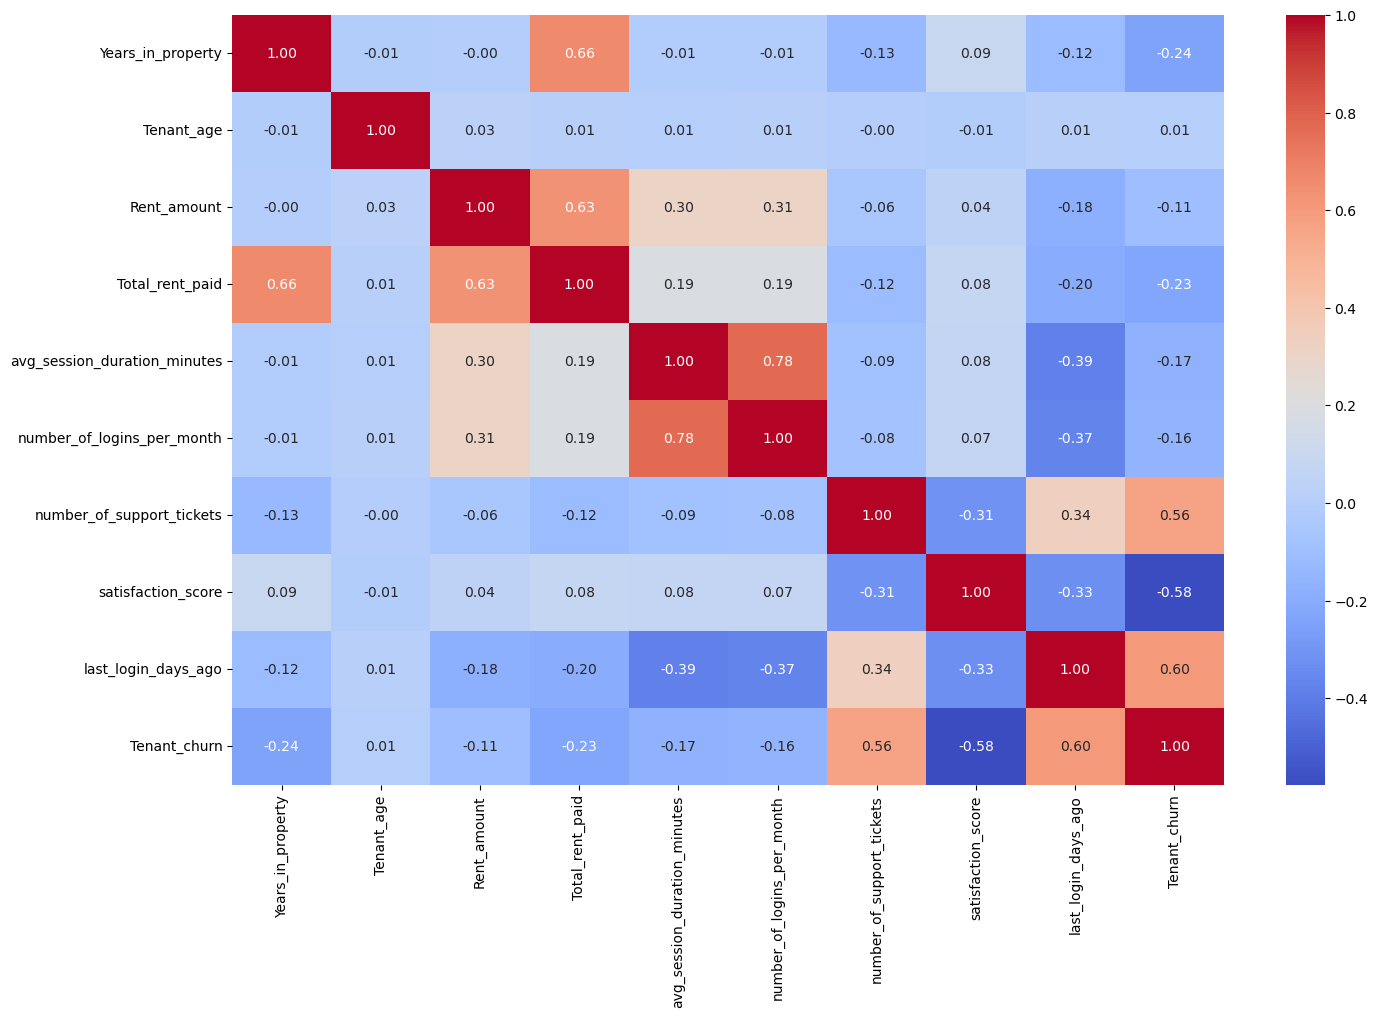

In [23]:
plt.figure(figsize=(16,10))
sns.heatmap(df_copy[num_columns].corr(),annot=True, cmap='coolwarm',fmt=".2f")
plt.show()

In [24]:
# features selection categorical with chi-square-test
cate_columns= df_copy.select_dtypes(include=object).columns
print("\ncategorical columns:", cate_columns.tolist())


categorical columns: ['Tenant_gender', 'region', 'income_level', 'subscription_type', 'usage_frequency', 'Rent_payment_method', 'Lease_type', 'promotional_response', 'discount_used']


In [25]:
# features selection with chi-square-test
from scipy.stats import chi2_contingency
results = []

for col in cate_columns:
    contingency = pd.crosstab(df[col], df['Tenant_churn'])
    chi2, p, dof, ex = chi2_contingency(contingency)
    results.append({'Feature': col,'p-value': p})

chi_results = pd.DataFrame(results).sort_values('p-value')
print(chi_results)

                Feature        p-value
6            Lease_type  3.960970e-291
4       usage_frequency  4.157931e-169
7  promotional_response   3.550742e-51
3     subscription_type   1.790491e-43
2          income_level   2.368516e-09
8         discount_used   1.832342e-02
5   Rent_payment_method   6.475515e-01
1                region   8.314820e-01
0         Tenant_gender   9.074936e-01


In [26]:
#confedience-interval - p_value
chi_results[chi_results['p-value']<0.05]

,Feature,p-value
6,Lease_type,3.960970e-291
4,usage_frequency,4.157931e-169
7,promotional_response,3.550742e-51
3,subscription_type,1.790491e-43
2,income_level,2.368516e-09
8,discount_used,1.832342e-02


In [27]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Years_in_property             15000 non-null  int64  
 1   Tenant_age                    15000 non-null  int64  
 2   Tenant_gender                 15000 non-null  object 
 3   region                        15000 non-null  object 
 4   income_level                  15000 non-null  object 
 5   subscription_type             15000 non-null  object 
 6   Rent_amount                   15000 non-null  float64
 7   Total_rent_paid               15000 non-null  float64
 8   usage_frequency               15000 non-null  object 
 9   avg_session_duration_minutes  15000 non-null  float64
 10  number_of_logins_per_month    15000 non-null  int64  
 11  number_of_support_tickets     15000 non-null  int64  
 12  satisfaction_score            15000 non-null  int64  
 13  R

In [28]:
#create a new list for a features
features=['Years_in_property','income_level','subscription_type','Rent_amount','Total_rent_paid','usage_frequency','avg_session_duration_minutes','number_of_logins_per_month','number_of_support_tickets',
         'satisfaction_score','Lease_type','last_login_days_ago','promotional_response','discount_used','Tenant_churn']
df_ml=df_copy[features]
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Years_in_property             15000 non-null  int64  
 1   income_level                  15000 non-null  object 
 2   subscription_type             15000 non-null  object 
 3   Rent_amount                   15000 non-null  float64
 4   Total_rent_paid               15000 non-null  float64
 5   usage_frequency               15000 non-null  object 
 6   avg_session_duration_minutes  15000 non-null  float64
 7   number_of_logins_per_month    15000 non-null  int64  
 8   number_of_support_tickets     15000 non-null  int64  
 9   satisfaction_score            15000 non-null  int64  
 10  Lease_type                    15000 non-null  object 
 11  last_login_days_ago           15000 non-null  int64  
 12  promotional_response          15000 non-null  object 
 13  d

In [29]:
features_cat=df_ml.select_dtypes(include=object).columns
for col in features_cat:
    print(f"{col}:\n{df_ml[col].unique()}")

income_level:
['low' 'medium' 'high']
subscription_type:
['basic' 'standard' 'premium']
usage_frequency:
['medium' 'low' 'high']
Lease_type:
['monthly' 'yearly']
promotional_response:
['no' 'yes']
discount_used:
['yes' 'no']


# feature engineering

In [30]:
df_ml_encoded = df_ml.copy()

In [31]:
# label_encoder
from sklearn.preprocessing import LabelEncoder
binary_columns = ['Lease_type','promotional_response','discount_used']
le = LabelEncoder()

for col in binary_columns:
    df_ml_encoded[col] = le.fit_transform(df_ml_encoded[col])

In [32]:
df_ml_encoded.head()

,Years_in_property,income_level,subscription_type,Rent_amount,Total_rent_paid,usage_frequency,avg_session_duration_minutes,number_of_logins_per_month,number_of_support_tickets,satisfaction_score,Lease_type,last_login_days_ago,promotional_response,discount_used,Tenant_churn
0,28,low,basic,35.22,1034.06,medium,55.3,12,1,5,0,4,0,1,0
1,34,low,standard,63.56,2065.11,medium,25.7,18,1,3,1,13,0,1,0
2,17,low,standard,74.37,1248.11,low,9.0,8,6,5,0,54,0,1,1
3,19,medium,premium,98.28,1540.50,high,99.4,30,1,3,0,6,0,0,0
4,20,medium,standard,61.47,1166.17,low,8.4,8,3,5,1,59,0,1,0


In [37]:
#one hot encoding
from sklearn.preprocessing import OneHotEncoder
num_encoded = ['income_level','subscription_type','usage_frequency']
ohe=OneHotEncoder(sparse_output=False, drop='first')  # drop='first' to avoid dummy variable trap
encoded_data = ohe.fit_transform(df_ml_encoded[num_encoded])
encoded_df = pd.DataFrame(encoded_data, columns=ohe.get_feature_names_out(num_encoded), index=df_ml_encoded.index)
df_ml_encoded = pd.concat([df_ml_encoded.drop(columns=num_encoded), encoded_df], axis=1)
df_ml_encoded.head()

,Years_in_property,Rent_amount,Total_rent_paid,avg_session_duration_minutes,number_of_logins_per_month,number_of_support_tickets,satisfaction_score,Lease_type,last_login_days_ago,promotional_response,discount_used,Tenant_churn,income_level_low,income_level_medium,subscription_type_premium,subscription_type_standard,usage_frequency_low,usage_frequency_medium
0,28,35.22,1034.06,55.3,12,1,5,0,4,0,1,0,1.0,0.0,0.0,0.0,0.0,1.0
1,34,63.56,2065.11,25.7,18,1,3,1,13,0,1,0,1.0,0.0,0.0,1.0,0.0,1.0
2,17,74.37,1248.11,9.0,8,6,5,0,54,0,1,1,1.0,0.0,0.0,1.0,1.0,0.0
3,19,98.28,1540.50,99.4,30,1,3,0,6,0,0,0,0.0,1.0,1.0,0.0,0.0,0.0
4,20,61.47,1166.17,8.4,8,3,5,1,59,0,1,0,0.0,1.0,0.0,1.0,1.0,0.0


In [38]:
X = df_ml_encoded.drop('Tenant_churn', axis=1)
y = df_ml_encoded['Tenant_churn']

## Machine Learning

In [39]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [40]:
# Scaling the features (important for Ridge and Lasso)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [42]:
y_pred = lr.predict(X_test_scaled)
y_prob = lr.predict_proba(X_test_scaled)[:,1]

In [45]:
from sklearn.metrics import accuracy_score,f1_score, roc_auc_score, confusion_matrix, classification_report
# metrics
accuracy=accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
cm_df = pd.DataFrame(confusion_matrix(y_test, y_pred), columns=['Predicted 0', 'Predicted 1'], index=['Actual 0', 'Actual 1'])
report = classification_report(y_test, y_pred)

print(f"Accuracy Score: {accuracy}")
print(f"F1 Score: {f1}")
print(f"\nROC AUC Score: {roc_auc}")
print(f"\nConfusion Matrix:\n{cm_df}")
print(f"\nClassification Report:\n{report}")

Accuracy Score: 0.9273333333333333
F1 Score: 0.8824163969795038

ROC AUC Score: 0.9724384592736722

Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0         1964           81
Actual 1          137          818

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.95      2045
           1       0.91      0.86      0.88       955

    accuracy                           0.93      3000
   macro avg       0.92      0.91      0.91      3000
weighted avg       0.93      0.93      0.93      3000



In [49]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.932
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      2045
           1       0.93      0.86      0.89       955

    accuracy                           0.93      3000
   macro avg       0.93      0.91      0.92      3000
weighted avg       0.93      0.93      0.93      3000

